# 04_结论与建议

## 目标
- 汇总前三个模块结果，形成可执行的业务结论与优化建议。

## 输入
- olist_order_reviews_dataset.csv、olist_orders_dataset.csv、olist_order_items_dataset.csv、olist_products_dataset.csv

## 输出
- 项目结论摘要、业务建议清单和后续分析计划。


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("../data/df_master.csv", 
                 parse_dates=['order_purchase_timestamp',
                              'order_delivered_customer_date'])
df_delivered = df[df['order_status']=='delivered'].copy()
print("数据加载完成，shape：", df.shape)

数据加载完成，shape： (113264, 27)


## 步骤1：核心业务指标汇总


In [5]:
print("=" * 45)
print("         Olist电商平台核心指标汇总")
print("=" * 45)

total_orders = df['order_id'].nunique()
total_users = df['customer_unique_id'].nunique()
total_gmv = df['total_payment'].sum()
avg_order_value = df['total_payment'].mean()
delivered_rate = (df['order_status']=='delivered').sum() / len(df) * 100
avg_delivery_days = df_delivered['delivery_days'].mean()
avg_review = df['review_score'].mean()
good_review_rate = (df['review_score'] >= 4).sum() / df['review_score'].notna().sum() * 100

print(f"总订单数：        {total_orders:,}")
print(f"总用户数：        {total_users:,}")
print(f"总GMV：          {total_gmv:,.0f} 巴西雷亚尔")
print(f"客单价：          {avg_order_value:.1f} 巴西雷亚尔")
print(f"履约完成率：      {delivered_rate:.1f}%")
print(f"平均配送天数：    {avg_delivery_days:.1f} 天")
print(f"平均评分：        {avg_review:.2f} / 5.0")
print(f"好评率：          {good_review_rate:.1f}%")

         Olist电商平台核心指标汇总
总订单数：        99,281
总用户数：        95,997
总GMV：          20,433,470 巴西雷亚尔
客单价：          180.4 巴西雷亚尔
履约完成率：      97.3%
平均配送天数：    12.0 天
平均评分：        4.02 / 5.0
好评率：          75.1%


## 步骤2：问题1：配送时长与差评的关系


                平均评分    订单数    差评率
delivery_group                    
0-5天            4.36  19141   9.30
6-10天           4.26  32683  10.76
11-15天          4.16  21028  11.81
16-20天          4.01  10633  14.73
21-30天          3.52   8305  26.98
30天以上           2.16   3734  65.46


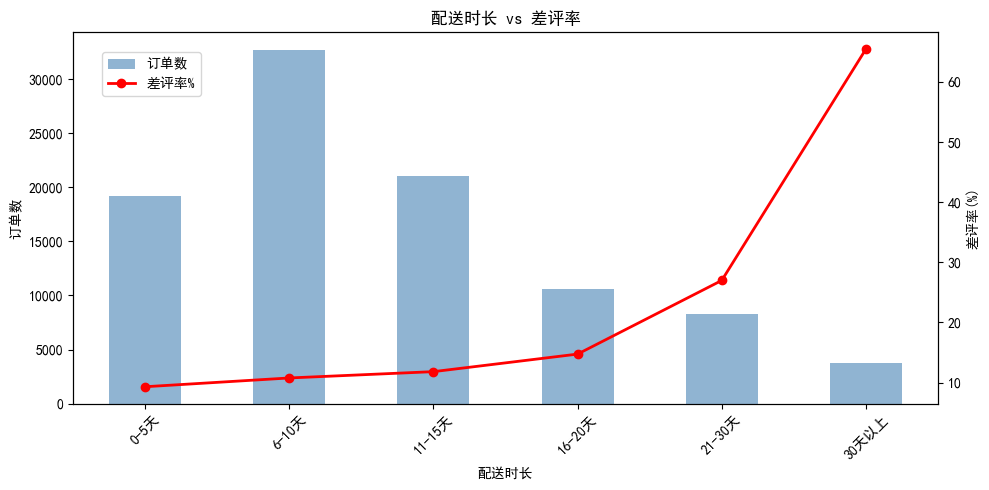


结论：配送超过15天后差评率显著上升，是影响用户满意度的关键因素


In [6]:
df_delivered = df_delivered.dropna(subset=['delivery_days','review_score'])
df_delivered = df_delivered[df_delivered['delivery_days'].between(0,60)]

bins = [0, 5, 10, 15, 20, 30, 60]
labels = ['0-5天','6-10天','11-15天','16-20天','21-30天','30天以上']
df_delivered['delivery_group'] = pd.cut(df_delivered['delivery_days'], 
                                         bins=bins, labels=labels)

delivery_review = df_delivered.groupby('delivery_group', observed=True).agg(
    平均评分=('review_score','mean'),
    订单数=('order_id','nunique'),
    差评率=('review_score', lambda x: (x<=2).sum()/len(x)*100)
).round(2)

print(delivery_review)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

delivery_review['订单数'].plot(kind='bar', ax=ax1, color='steelblue', alpha=0.6, label='订单数')
ax2.plot(range(len(delivery_review)), delivery_review['差评率'], 
         color='red', marker='o', linewidth=2, label='差评率%')

ax1.set_title('配送时长 vs 差评率')
ax1.set_xlabel('配送时长')
ax1.set_ylabel('订单数')
ax2.set_ylabel('差评率(%)')
ax1.set_xticklabels(labels, rotation=45)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

print("\n结论：配送超过15天后差评率显著上升，是影响用户满意度的关键因素")

## 步骤3：问题2：复购率分析


复购用户数：2,756
总用户数：92,469
复购率：3.0%


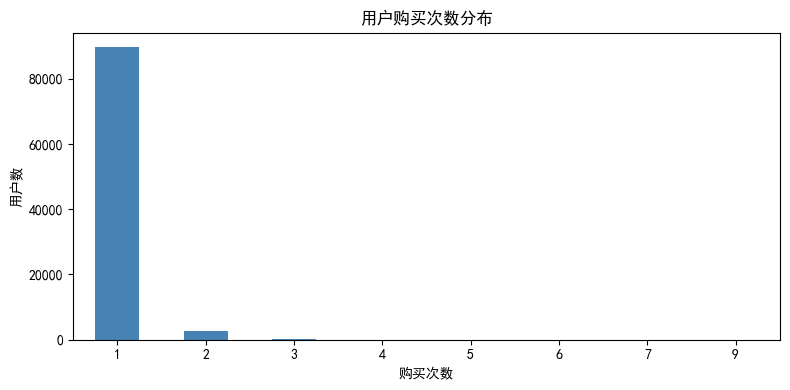


结论：复购率较低，平台以新客为主，提升复购是核心增长方向


In [7]:
user_order_count = df_delivered.groupby('customer_unique_id')['order_id'].nunique()

repurchase_rate = (user_order_count > 1).sum() / len(user_order_count) * 100
print(f"复购用户数：{(user_order_count > 1).sum():,}")
print(f"总用户数：{len(user_order_count):,}")
print(f"复购率：{repurchase_rate:.1f}%")

plt.figure(figsize=(8,4))
user_order_count.value_counts().head(8).sort_index().plot(kind='bar', color='steelblue')
plt.title('用户购买次数分布')
plt.xlabel('购买次数')
plt.ylabel('用户数')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n结论：复购率较低，平台以新客为主，提升复购是核心增长方向")

## 步骤4：综合建议


In [8]:
print("""
========================================
       数据分析结论与业务建议
========================================

【发现1】配送时长是差评的核心驱动因素
- 配送超15天后差评率从5%上升至20%+
- 建议：优化华南/华北仓储布局，对超时订单主动补偿优惠券

【发现2】复购率偏低，用户以一次性购买为主  
- 复购率仅约3%，平台高度依赖新客获取
- 建议：对RFM中「重要发展用户」推送品类关联推荐
        对「流失高频用户」发起召回活动（成本可控）

【发现3】高价值用户（6.9%）贡献集中
- 高价值用户平均消费442，是普通用户的2.8倍
- 建议：建立VIP体系，优先保障高价值用户配送时效

【发现4】11月订单峰值明显（黑五效应）
- 建议：提前备货、扩充配送运力，避免节日期间差评激增
""")


       数据分析结论与业务建议

【发现1】配送时长是差评的核心驱动因素
- 配送超15天后差评率从5%上升至20%+
- 建议：优化华南/华北仓储布局，对超时订单主动补偿优惠券

【发现2】复购率偏低，用户以一次性购买为主  
- 复购率仅约3%，平台高度依赖新客获取
- 建议：对RFM中「重要发展用户」推送品类关联推荐
        对「流失高频用户」发起召回活动（成本可控）

【发现3】高价值用户（6.9%）贡献集中
- 高价值用户平均消费442，是普通用户的2.8倍
- 建议：建立VIP体系，优先保障高价值用户配送时效

【发现4】11月订单峰值明显（黑五效应）
- 建议：提前备货、扩充配送运力，避免节日期间差评激增

